In [2]:
from fibsem.structures import FibsemImage
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
import tifffile as tiff
import cv2

Default configuration default-configuration. Configuration Path: C:\Users\rohit\Documents\Code\newFIBSEM\fibsem-os-NYSBC\fibsem\config\microscope-configuration.yaml


In [3]:
ib_0841_path = r"C:\Users\rohit\Documents\fibsem_model_training\Serial_Liftout\liftout_images_new\IB_0845.tif"
# ib_0841_path = r"C:\Users\rohit\Documents\fibsem_model_training\Serial_Liftout\liftout_images_new\EB_0127.tif"
ib_0841 = tiff.imread(ib_0841_path)
print(ib_0841.shape)




(1094, 1536, 3)


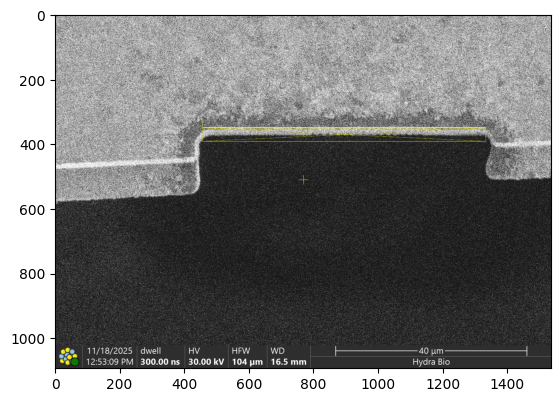

In [4]:
plt.imshow(ib_0841, cmap="gray")
plt.show()

(1094, 1536)


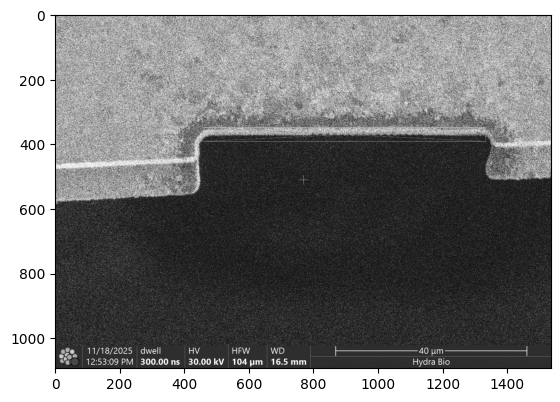

In [5]:
# turn image to greyscale
if len(ib_0841.shape) == 3:

    ib_0841_gray = cv2.cvtColor(ib_0841, cv2.COLOR_BGR2GRAY)
else:
    ib_0841_gray = ib_0841
print(ib_0841_gray.shape)
plt.imshow(ib_0841_gray, cmap="gray")
plt.show()

70
(1024, 1536)


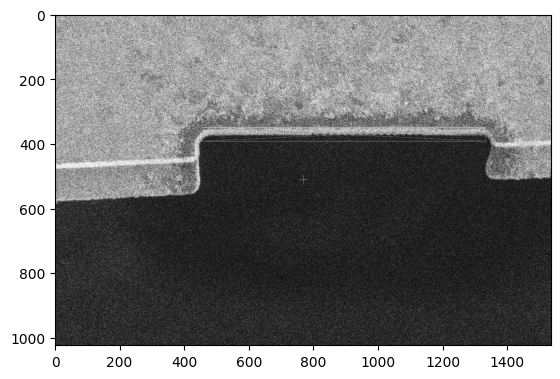

In [6]:
# crop bottom 10% of image but make sure height is divisble by 32

rows, cols = ib_0841_gray.shape
crop_height = int(rows - (cols / 1.5))
print(crop_height)
ib_0841_cropped = ib_0841_gray[: rows - crop_height, :]
print(ib_0841_cropped.shape)
plt.imshow(ib_0841_cropped, cmap="gray")
plt.show()

In [7]:
fb_image = FibsemImage(data=ib_0841_cropped)

In [8]:
save_path = os.path.join(r"C:\Users\rohit\Documents\fibsem_model_training\Serial_Liftout\liftout_images_new_bw", "EB_0127_cropped.tif")

fb_image.save(save_path)

In [9]:
images_dir = r"C:\Users\rohit\Documents\fibsem_model_training\Serial_Liftout\liftout_2\sorted"

save_dir = r"C:\Users\rohit\Documents\fibsem_model_training\Serial_Liftout\liftout_2_bw"


for filename in os.listdir(images_dir):

    image_path = os.path.join(images_dir, filename)
    image = tiff.imread(image_path)

    if len(image.shape) == 3:

        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    else:
        image_gray = image

    rows, cols = image_gray.shape
    crop_height = int(rows - (cols / 1.5))
    image_cropped = image_gray[: rows - crop_height, :]

    fb_image = FibsemImage(data=image_cropped)

    save_path = os.path.join(save_dir, filename)

    fb_image.save(save_path)


    

    